<a href="https://colab.research.google.com/github/Rim-sudo/-25007753-Fadlou-Marwa-25007758-Edman-Rim/blob/main/Pr%C3%A9diction%20du%20temps%20de%20livraison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aperçu dataset :
   distance_km  traffic_index  num_stops  driver_experience  is_raining  \
0     9.988963       4.542720          3                  6           1   
1    23.817143       5.260921          1                  4           1   
2    18.567855       8.690927          4                  1           0   
3    15.367804       4.060039          2                  7           0   
4     4.744447       8.826847          2                  5           1   

   is_peak_hour vehicle_type        city  delivery_time_min  
0             0          van       Rabat          49.635734  
1             1          van  Casablanca          87.417389  
2             1          van  Casablanca          92.519227  
3             1          car  Casablanca          59.180610  
4             0         bike       Rabat          41.194146  

--- Résultats du Modèle ---
MAE (Erreur moyenne) : 2.99 minutes
MSE : 14.00
R² : 0.950

Importance des variables :
             feature  importance
0        di

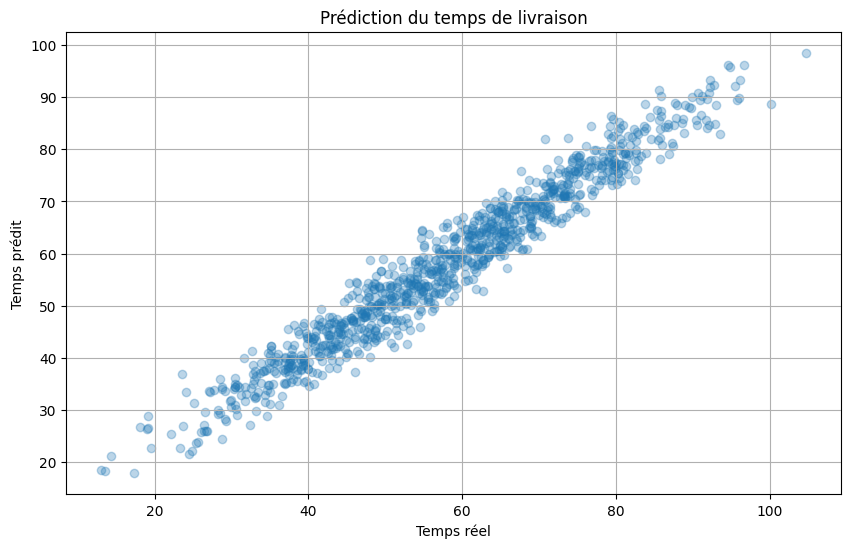

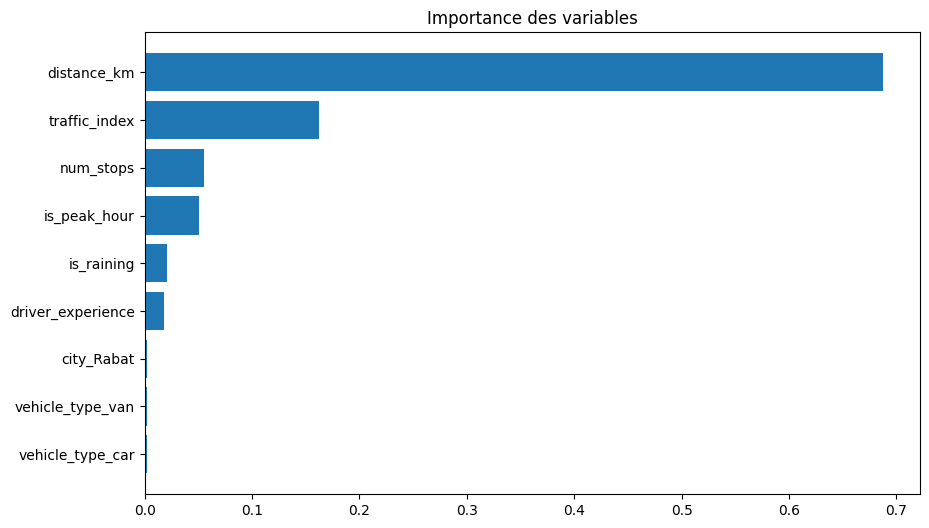

In [1]:
# =========================================================
# 1. IMPORT DES LIBRAIRIES
# =========================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

np.random.seed(42)

# =========================================================
# 2. GÉNÉRATION D'UN DATASET RÉALISTE (5000 LIVRAISONS)
# =========================================================
n = 5000

data = pd.DataFrame({
    "distance_km": np.random.uniform(1, 25, n),
    "traffic_index": np.random.uniform(1, 10, n),  # 1 = fluide / 10 = bouchons
    "num_stops": np.random.randint(0, 5, n),
    "driver_experience": np.random.randint(1, 10, n),  # années
    "is_raining": np.random.randint(0, 2, n),
    "is_peak_hour": np.random.randint(0, 2, n),
    "vehicle_type": np.random.choice(["bike","car","van"], n),
    "city": np.random.choice(["Casablanca","Rabat"], n)
})

# =========================================================
# 3. CRÉATION DE LA VARIABLE CIBLE (TEMPS LIVRAISON)
# Formule réaliste supply chain
# =========================================================
base_time = 10 + data["distance_km"] * 2
traffic_effect = data["traffic_index"] * 2.5
stops_effect = data["num_stops"] * 3
rain_effect = data["is_raining"] * 6
peak_effect = data["is_peak_hour"] * 8
experience_effect = -data["driver_experience"] * 0.8

data["delivery_time_min"] = (
    base_time +
    traffic_effect +
    stops_effect +
    rain_effect +
    peak_effect +
    experience_effect +
    np.random.normal(0, 3, n)
)

print("Aperçu dataset :")
print(data.head())

# =========================================================
# 4. ENCODAGE VARIABLES CATÉGORIELLES
# =========================================================
data = pd.get_dummies(data, columns=["vehicle_type","city"], drop_first=True)

# =========================================================
# 5. FEATURES / TARGET
# =========================================================
X = data.drop("delivery_time_min", axis=1)
y = data["delivery_time_min"]

# =========================================================
# 6. TRAIN / TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================================
# 7. ENTRAÎNEMENT DU MODÈLE
# =========================================================
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# =========================================================
# 8. PRÉDICTION ET ÉVALUATION
# =========================================================
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n--- Résultats du Modèle ---")
print(f"MAE (Erreur moyenne) : {mae:.2f} minutes")
print(f"MSE : {mse:.2f}")
print(f"R² : {r2:.3f}")

# =========================================================
# 9. IMPORTANCE DES VARIABLES
# =========================================================
importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nImportance des variables :")
print(importance_df)

# =========================================================
# 10. VISUALISATION : PRÉDICTION vs RÉEL
# =========================================================
plt.figure(figsize=(10,6))
plt.scatter(y_test, predictions, alpha=0.3)
plt.xlabel("Temps réel")
plt.ylabel("Temps prédit")
plt.title("Prédiction du temps de livraison")
plt.grid()
plt.show()

# =========================================================
# 11. VISUALISATION IMPORTANCE VARIABLES
# =========================================================
plt.figure(figsize=(10,6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.title("Importance des variables")
plt.gca().invert_yaxis()
plt.show()